# Corrective RAG -> Incorrect -> Web Search

When retrieval comes back weak, the fix isn't to guess from bad chunks — it's to go find the answer somewhere else. This notebook adds a web search fallback for the INCORRECT grade, plus a terminal node for AMBIGUOUS that surfaces the grading reason instead of refining a shaky mix of chunks.

Two nodes are added on the INCORRECT branch:

1. **Rewrite** — turn the question into a short, keyword-style web search query (an LLM call, not a plain pass-through — recency hints need an explicit date constraint).
2. **Web Search** — run that query through Tavily and wrap each result into a `Document`, the same shape retrieval produces, so `refine` and `generate` don't need to know whether their context came from the books or the web.

Routing:

- **CORRECT** → `refine` (over `good_docs`) → `generate`
- **AMBIGUOUS** → a terminal `ambiguous` node that surfaces the grading reason rather than guessing
- **INCORRECT** → `rewrite` → `web_search` → `refine` (over `web_docs`) → `generate`

In [1]:
import logging
import re
from pathlib import Path

from typing import List, Literal, TypedDict

import fitz
from pydantic import BaseModel
from langchain_chroma import Chroma
from langchain_tavily import TavilySearch
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END

from dotenv import load_dotenv

load_dotenv()

logging.getLogger("google_genai.models").setLevel(logging.ERROR)

UPPER_TH = 0.7
LOWER_TH = 0.3

## Load Documents

In [2]:
def load_pdf(file_path: str) -> list[Document]:
    path = Path(file_path)
    if not path.exists():
        raise FileNotFoundError(f"PDF not found at: {file_path}")

    documents = []
    with fitz.open(path) as doc:
        for page_num, page in enumerate(doc):
            text = page.get_text("text")
            if not text.strip():
                continue

            metadata = {"source": str(path), "page": page_num + 1, "total_pages": len(doc)}
            documents.append(Document(page_content=text, metadata=metadata))

    return documents


docs = (
    load_pdf("./documents/book1.pdf") +
    load_pdf("./documents/book2.pdf") +
    load_pdf("./documents/book3.pdf")
)

len(docs)

2112

## Split into Chunks

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

len(chunks)

6711

## Embeddings & Vector Store

In [4]:
embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")
vector_store = Chroma.from_documents(chunks, embeddings)

In [5]:
retriever = vector_store.as_retriever(search_type="similarity", search_kwargs={"k": 4})

## LLM

In [6]:
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)

## Web Search Tool

In [7]:
tavily_search = TavilySearch(max_results=3)

## Graph State

In [8]:
class State(TypedDict):
    question: str
    docs: List[Document]

    scores: List[float]
    good_docs: List[Document]
    grade: Literal["CORRECT", "INCORRECT", "AMBIGUOUS"]
    grade_reason: str

    web_query: str
    web_docs: List[Document]

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str

## Retrieve Node

In [9]:
def retrieve(state: State) -> dict:
    question = state["question"]
    retrieved_docs = retriever.invoke(question)
    return {"docs": retrieved_docs}

## Score Prompt

In [10]:
class DocScore(BaseModel):
    """Relevance score and rationale for one retrieved chunk."""

    score: float
    reason: str


score_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Score how well the chunk, on its own, helps answer the question, in [0.0, 1.0]:\n"
            "- 1.0: the chunk alone is sufficient to answer fully or mostly.\n"
            "- 0.0: the chunk is irrelevant.\n"
            "Be conservative with high scores. Also give a short reason.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

score_chain = score_prompt | llm.with_structured_output(DocScore)

## Evaluate Node

In [11]:
def evaluate(state: State) -> dict:
    question = state["question"]
    retrieved_docs = state["docs"]

    scores: List[float] = []
    good_docs: List[Document] = []

    for doc in retrieved_docs:
        verdict = score_chain.invoke({"question": question, "chunk": doc.page_content})
        scores.append(verdict.score)
        if verdict.score > LOWER_TH:
            good_docs.append(doc)

    if scores and max(scores) > UPPER_TH:
        grade = "CORRECT"
        reason = f"Best chunk scored {max(scores):.2f}, above the CORRECT threshold ({UPPER_TH})."
    elif scores and all(score < LOWER_TH for score in scores):
        grade = "INCORRECT"
        good_docs = []
        reason = f"All {len(scores)} chunks scored below the INCORRECT threshold ({LOWER_TH})."
    else:
        grade = "AMBIGUOUS"
        reason = "Mixed relevance: no chunk cleared the upper threshold, but not all fell below the lower one."

    return {"scores": scores, "good_docs": good_docs, "grade": grade, "grade_reason": reason}

## Rewrite Prompt

In [12]:
class WebQuery(BaseModel):
    """A short, keyword-style web search query rewritten from the user's question."""

    query: str


rewrite_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "Rewrite the user question into a web search query made of keywords.\n"
            "Rules:\n"
            "- Keep it short (6-14 words).\n"
            "- If the question implies recency (e.g. recent/latest/last week/last month), "
            "add an explicit constraint like (last 30 days).\n"
            "- Do NOT answer the question, only rewrite it.",
        ),
        ("human", "Question: {question}"),
    ]
)

rewrite_chain = rewrite_prompt | llm.with_structured_output(WebQuery)

## Rewrite Node

In [13]:
def rewrite(state: State) -> dict:
    result = rewrite_chain.invoke({"question": state["question"]})
    return {"web_query": result.query}

## Web Search Node

In [14]:
def web_search(state: State) -> dict:
    query = state["web_query"] or state["question"]
    response = tavily_search.invoke({"query": query})

    web_docs: List[Document] = []
    for result in response.get("results", []):
        title = result.get("title", "")
        url = result.get("url", "")
        content = result.get("content", "")
        text = f"TITLE: {title}\nURL: {url}\nCONTENT:\n{content}"
        web_docs.append(Document(page_content=text, metadata={"title": title, "url": url}))

    return {"web_docs": web_docs}

## Helper: Decompose into Sentences

In [15]:
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

## Helper: Filter Strips with the LLM

In [16]:
class KeepOrDrop(BaseModel):
    """Relevance verdict for a single sentence."""

    keep: bool


filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Judge the sentence on its own, using no other context.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

## Refine Node

In [17]:
def refine(state: State) -> dict:
    question = state["question"]

    source_docs = state["good_docs"] if state["grade"] == "CORRECT" else state["web_docs"]
    combined_text = "\n\n".join(doc.page_content for doc in source_docs).strip()

    strips = decompose_to_sentences(combined_text)

    kept_strips: List[str] = []
    for sentence in strips:
        verdict = filter_chain.invoke({"question": question, "sentence": sentence})
        if verdict.keep:
            kept_strips.append(sentence)

    refined_context = "\n".join(kept_strips).strip()

    return {
        "strips": strips,
        "kept_strips": kept_strips,
        "refined_context": refined_context,
    }

## Answer Prompt

In [22]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful research assistant. Answer ONLY using the provided refined bullets.\n"
            "If the bullets are empty or insufficient, say: 'I don't know based on the provided context.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

## Generate Node

In [18]:
def generate(state: State) -> dict:
    question = state["question"]
    refined_context = state["refined_context"]

    response = (answer_prompt | llm).invoke(
        {"question": question, "refined_context": refined_context}
    )

    return {"answer": response.content}

## Ambiguous Node

In [19]:
def ambiguous(state: State) -> dict:
    return {"answer": f"Ambiguous: {state['grade_reason']}"}

## Build the Graph

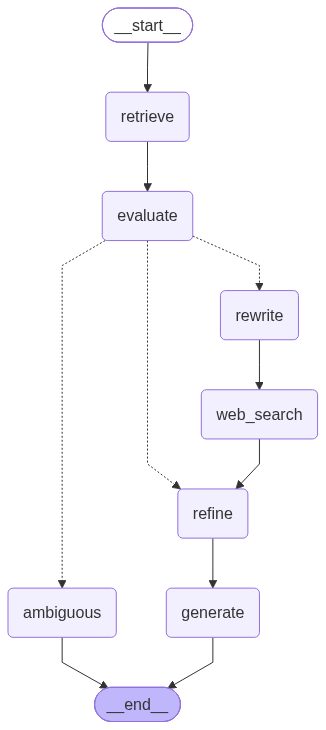

In [20]:
def route_on_grade(state: State) -> str:
    if state["grade"] == "CORRECT":
        return "refine"
    if state["grade"] == "INCORRECT":
        return "rewrite"
    return "ambiguous"


graph = StateGraph(State)
graph.add_node("retrieve", retrieve)
graph.add_node("evaluate", evaluate)
graph.add_node("rewrite", rewrite)
graph.add_node("web_search", web_search)
graph.add_node("refine", refine)
graph.add_node("generate", generate)
graph.add_node("ambiguous", ambiguous)

graph.add_edge(START, "retrieve")
graph.add_edge("retrieve", "evaluate")
graph.add_conditional_edges(
    "evaluate",
    route_on_grade,
    {"refine": "refine", "rewrite": "rewrite", "ambiguous": "ambiguous"},
)
graph.add_edge("rewrite", "web_search")
graph.add_edge("web_search", "refine")
graph.add_edge("refine", "generate")
graph.add_edge("generate", END)
graph.add_edge("ambiguous", END)

app = graph.compile()

app

## Run

In [31]:
def ask(question: str) -> None:
    result = app.invoke(
        {
            "question": question,
            "docs": [],
            "scores": [],
            "good_docs": [],
            "grade": "AMBIGUOUS",
            "grade_reason": "",
            "web_query": "",
            "web_docs": [],
            "strips": [],
            "kept_strips": [],
            "refined_context": "",
            "answer": "",
        }
    )
    print("GRADE:", result["grade"])
    print("REASON:", result["grade_reason"])
    if result.get("web_query"):
        print("WEB QUERY:", result["web_query"])
    print("\nANSWER:\n", result["answer"])


In [32]:
ask("What happened in AI news last week?")

GRADE: INCORRECT
REASON: All 4 chunks scored below the INCORRECT threshold (0.3).
WEB QUERY: AI news summary last week (last 7 days)

ANSWER:
 I don't know based on the provided context.


In [28]:
ask("What is the bias-variance tradeoff?")

GRADE: CORRECT
REASON: Best chunk scored 1.00, above the CORRECT threshold (0.7).

ANSWER:
 *   The bias-variance tradeoff is an important theoretical result in statistics and Machine Learning, where a model's generalization error can be expressed as the sum of bias, variance, and a constant noise term.
*   There is a trade-off between bias and variance:
    *   Increasing a model’s complexity typically increases its variance and reduces its bias. Very flexible models have low bias and high variance.
    *   Reducing a model’s complexity increases its bias and reduces its variance. Relatively rigid models have high bias and low variance.
*   The goal is to minimize the expected loss by finding the best balance between bias and variance, leading to optimal predictive capability.
